In [1]:
import os
import json

# Paths
dataset_json = r"C:\Users\chamu\D\UOR\FYP\fyp\data\rexgrounding-ct\dataset.json"
train_annotations_dir = r"C:\Users\chamu\D\UOR\FYP\fyp\data\patch-masks\annotations-train"
val_annotations_dir = r"C:\Users\chamu\D\UOR\FYP\fyp\data\patch-masks\annotations-valid"

# Load dataset
with open(dataset_json, "r") as f:
    dataset = json.load(f)

# Get case names from dataset.json
dataset_cases = {
    os.path.splitext(os.path.splitext(item["name"])[0])[0]
    for item in dataset["train"] + dataset["val"] + dataset["test"]
}

# Get folder names
annotation_folders = {
    name
    for name in os.listdir(train_annotations_dir) + os.listdir(val_annotations_dir)
    if os.path.isdir(os.path.join(train_annotations_dir, name)) or os.path.isdir(os.path.join(val_annotations_dir, name))
}

# Find common cases
common = dataset_cases & annotation_folders

print(f"Cases in dataset.json: {len(dataset_cases)}")
print(f"Folders in annotations-train & annotations-valid: {len(annotation_folders)}")
print(f"Common cases: {len(common)}")

# Optional: print the common names
for case in sorted(common):
    print(case)

# Optional: show missing cases
missing_in_annotations = dataset_cases - annotation_folders
missing_in_dataset = annotation_folders - dataset_cases

print(f"\nMissing annotation folders: {len(missing_in_annotations)}")
print(f"Extra annotation folders: {len(missing_in_dataset)}")

Cases in dataset.json: 3142
Folders in annotations-train & annotations-valid: 2201
Common cases: 79
train_10187_a_1
train_1019_a_1
train_10362_a_1
train_1045_a_1
train_10702_a_1
train_10742_a_1
train_10763_a_1
train_1085_a_1
train_11429_a_1
train_11619_a_1
train_11945_a_1
train_12127_a_1
train_12136_a_1
train_12165_a_1
train_12222_a_1
train_12251_a_1
train_12304_a_1
train_12440_a_1
train_12593_a_1
train_13715_a_1
train_1395_a_1
train_1455_a_1
train_1493_a_1
train_1623_a_1
train_1658_a_1
train_1756_a_1
train_1918_a_1
train_1933_a_1
train_1970_a_1
train_2224_a_1
train_2234_a_1
train_2316_a_1
train_2343_a_1
train_2474_a_1
train_284_a_1
train_33_a_1
train_346_a_1
train_355_a_1
train_422_a_1
train_525_a_1
train_5295_a_1
train_5356_a_1
train_5359_a_1
train_5426_a_1
train_5450_a_1
train_560_a_1
train_5634_a_1
train_5645_a_1
train_5716_a_1
train_5823_a_1
train_6000_a_1
train_6008_a_1
train_6169_a_1
train_6171_a_1
train_6175_a_1
train_621_a_1
train_6316_a_1
train_6335_a_1
train_6357_a_1
train_6

Category distribution:
1a: 8
1b: 18
1c: 13
1d: 6
1e: 11
1f: 3
2a: 35
2b: 74
2c: 77
2d: 33
2e: 2
2h: 5


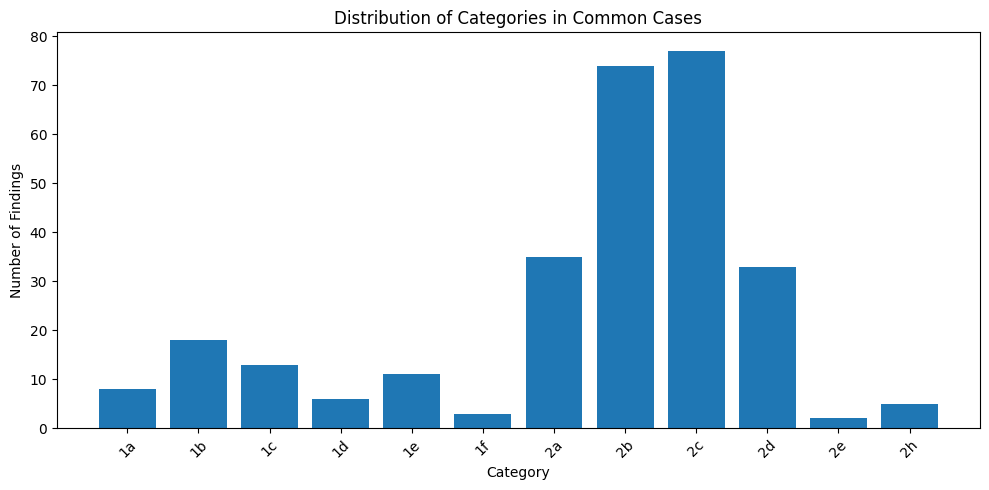

In [2]:
from collections import Counter
import matplotlib.pyplot as plt

# Combine all dataset entries
all_entries = dataset["train"] + dataset["val"] + dataset["test"]

# Count category occurrences for common cases
category_counts = Counter()

for item in all_entries:
    case_name = os.path.splitext(os.path.splitext(item["name"])[0])[0]

    if case_name in common:
        for category in item["categories"].values():
            category_counts[category] += 1

# Print counts
print("Category distribution:")
for category in sorted(category_counts):
    print(f"{category}: {category_counts[category]}")

# Plot
categories = sorted(category_counts.keys())
counts = [category_counts[c] for c in categories]

plt.figure(figsize=(10, 5))
plt.bar(categories, counts)
plt.xlabel("Category")
plt.ylabel("Number of Findings")
plt.title("Distribution of Categories in Common Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
import os

# Combine all dataset entries
all_entries = dataset["train"] + dataset["val"] + dataset["test"]

only_2c_cases = []

for item in all_entries:
    case_name = os.path.splitext(os.path.splitext(item["name"])[0])[0]

    if case_name not in common:
        continue

    categories = list(item["categories"].values())

    # Exactly one finding, and it is 2c
    if len(categories) == 1 and categories[0] == "2c":
        only_2c_cases.append(case_name)

print(f"Cases with only one 2c finding: {len(only_2c_cases)}")

# Print the case names
for case in sorted(only_2c_cases):
    print(case)

Cases with only one 2c finding: 5
train_12165_a_1
train_33_a_1
train_525_a_1
train_6008_a_1
train_6627_a_1


In [7]:
%matplotlib inline

import glob
import os

import matplotlib

matplotlib.use("Agg")
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from scipy.ndimage import zoom

# ── Reconstructed CT-RATE / CT-CLIP preprocessing constants ─────────────────
TARGET_SPACING_XY = 0.75   # mm, CT-CLIP paper
TARGET_SPACING_Z = 1.5     # mm, CT-CLIP paper
CTCLIP_SHAPE_DHW = (240, 480, 480)   # (D, H, W) = axial, coronal, sagittal
HU_CLIP = (-1000.0, 1000.0)          # CT-CLIP paper clip range
DOWNSAMPLE_FACTOR = 2.5              # UNVERIFIED - see module docstring
DISPLAY_SHAPE_DHW = (96, 192, 192)   # PatchChestCT display volume, per their script

PALETTE = {
    "arterial_wall_calcification":  "red",
    "coronary_wall_calcification":  "orange",
    "pericardial_effusion":         "yellow",
    "hiatal_hernia":                "lime",
    "lymphadenopathy":              "cyan",
    "atelectasis":                  "blue",
    "lung_opacity":                 "white",
    "consolidation":                "magenta",
    "bronchiectasis":               "pink",
}


# ── Generic helpers ──────────────────────────────────────────────────────────

def _center_crop_or_pad(arr: np.ndarray, target_shape: tuple, pad_value: float = 0.0) -> np.ndarray:
    """Center-crop or zero/pad-value-pad a 3D array to target_shape, per-axis."""
    out = arr
    for axis, tgt in enumerate(target_shape):
        cur = out.shape[axis]
        if cur > tgt:
            start = (cur - tgt) // 2
            sl = [slice(None)] * 3
            sl[axis] = slice(start, start + tgt)
            out = out[tuple(sl)]
        elif cur < tgt:
            before = (tgt - cur) // 2
            after = tgt - cur - before
            pad_widths = [(0, 0)] * 3
            pad_widths[axis] = (before, after)
            out = np.pad(out, pad_widths, mode="constant", constant_values=pad_value)
    return out


def _resample_to_spacing(arr: np.ndarray, current_spacing: tuple, target_spacing: tuple,
                          is_mask: bool) -> np.ndarray:
    """Resample a (D,H,W) array from current_spacing to target_spacing (mm, per axis)."""
    zoom_factors = [current_spacing[i] / target_spacing[i] for i in range(3)]
    order = 0 if is_mask else 1   # nearest for masks (preserve labels), trilinear for intensity
    return zoom(arr, zoom_factors, order=order, mode="nearest")


# ── Stage 1: raw nibabel volume -> CT-CLIP's (240,480,480) training format ──

def _load_lps(path: str):
    """Load a .nii.gz, return (array float32, spacing (x,y,z), axcodes)."""
    img = nib.load(path)
    axcodes = nib.aff2axcodes(img.affine)
    if axcodes != ("L", "P", "S"):
        # Not expected for CT-RATE, but reorient defensively if it ever differs.
        img = nib.as_closest_canonical(img)  # RAS
        # Flip to LPS to match the convention CT-RATE's own pipeline assumes.
        arr = img.get_fdata().astype(np.float32)
        arr = np.flip(arr, axis=(0, 1))
        zooms = img.header.get_zooms()[:3]
        return arr, zooms
    arr = img.get_fdata().astype(np.float32)
    zooms = img.header.get_zooms()[:3]   # (x, y, z) spacing in mm
    return arr, zooms


def _to_ctclip_intermediate(arr_xyz: np.ndarray, spacing_xyz: tuple, is_mask: bool) -> np.ndarray:
    """
    Reconstructs CT-RATE's official preprocessing: (X,Y,Z) LPS volume ->
    (240, 480, 480) (D,H,W) volume at 0.75x0.75x1.5mm spacing.
    """
    # (X,Y,Z) -> (Z,X,Y) i.e. (D,H,W), axial-first
    arr = np.transpose(arr_xyz, (2, 0, 1))
    current_spacing_zxy = (spacing_xyz[2], spacing_xyz[0], spacing_xyz[1])
    target_spacing_zxy = (TARGET_SPACING_Z, TARGET_SPACING_XY, TARGET_SPACING_XY)

    arr = _resample_to_spacing(arr, current_spacing_zxy, target_spacing_zxy, is_mask=is_mask)

    if not is_mask:
        arr = np.clip(arr, HU_CLIP[0], HU_CLIP[1])

    arr = _center_crop_or_pad(arr, CTCLIP_SHAPE_DHW, pad_value=HU_CLIP[0] if not is_mask else 0)
    return arr


# ── Stage 2: CT-CLIP intermediate -> PatchChestCT's (96,192,192) display volume ──

def _to_patchchestct_display_space(arr_dhw: np.ndarray, is_mask: bool) -> np.ndarray:
    """
    From (240,480,480) (D,H,W) CT-CLIP-format volume to PatchChestCT's
    (96,192,192) canonical display volume. Mirrors verify_alignment.py's
    _preprocess_to_display_space(), with the UNVERIFIED 2.5x downsample
    inserted first (see module docstring).
    """
    zoom_factor = 1.0 / DOWNSAMPLE_FACTOR
    order = 0 if is_mask else 1
    arr = zoom(arr_dhw, (zoom_factor,) * 3, order=order, mode="nearest")

    # ---- from here down, this exactly mirrors PatchChestCT's own script ----
    arr = np.transpose(arr, (1, 2, 0))               # (D,H,W) -> (H,W,D)
    arr = np.rot90(arr, k=-1, axes=(0, 1))            # 90deg clockwise, axial plane
    arr = _center_crop_or_pad(arr, (192, 192, 96), pad_value=0)
    arr = np.transpose(arr, (2, 0, 1))                # (H,W,D) -> (D,H,W)
    arr = np.flip(arr, axis=2).copy()                 # left-right flip
    return arr   # (96, 192, 192)


def preprocess_ct_to_display_space(ct_path: str) -> np.ndarray:
    arr_xyz, spacing = _load_lps(ct_path)   # nibabel.get_fdata() already applies slope/intercept -> true HU
    intermediate = _to_ctclip_intermediate(arr_xyz, spacing, is_mask=False)
    return _to_patchchestct_display_space(intermediate, is_mask=False)


def preprocess_mask_to_display_space(mask_path: str) -> np.ndarray:
    img = nib.load(mask_path)
    arr_xyz = img.get_fdata().astype(np.float32)
    if arr_xyz.ndim == 4:
        arr_xyz = arr_xyz[0]   # first finding channel
    spacing = img.header.get_zooms()[:3]
    intermediate = _to_ctclip_intermediate(arr_xyz, spacing, is_mask=True)
    return _to_patchchestct_display_space(intermediate, is_mask=True)


# ── Annotation + plotting ────────────────────────────────────────────────────

def _load_patch_annotations(ann_dir: str) -> dict:
    anns = {}
    for npz_path in sorted(glob.glob(os.path.join(ann_dir, "*.npz"))):
        disease = os.path.splitext(os.path.basename(npz_path))[0]
        anns[disease] = np.load(npz_path)["arr_0"].astype(bool)
    return anns


def _apply_window(arr: np.ndarray, wl: float = -400, ww: float = 1200) -> np.ndarray:
    lo, hi = wl - ww / 2, wl + ww / 2
    arr = np.clip(arr, lo, hi)
    return (arr - lo) / (hi - lo)

# ── 3D alignment visualization ───────────────────────────────────────────────

from scipy.ndimage import zoom
from mpl_toolkits.mplot3d import Axes3D


def _upsample_patch_annotation_to_voxel_grid(ann: np.ndarray) -> np.ndarray:
    """
    PatchChestCT annotation:
        (24,12,12)

    Display volume:
        (96,192,192)

    Each patch corresponds to:
        z: 4 slices
        y: 16 pixels
        x: 16 pixels
    """
    return zoom(
        ann.astype(np.uint8),
        zoom=(4, 16, 16),
        order=0
    ).astype(bool)

Loading CT: C:\Users\chamu\D\UOR\FYP\fyp\data\data_volumes\dataset\train_fixed\train_12165\train_12165_a\train_12165_a_1.nii.gz
Loading RexgroundingCT mask: C:\Users\chamu\D\UOR\FYP\fyp\data\segmentations\segmentations\train_12165_a_1.nii.gz
Loading PatchChestCT annotations from: C:\Users\chamu\D\UOR\FYP\fyp\data\patch-masks\annotations-train\train_12165_a_1


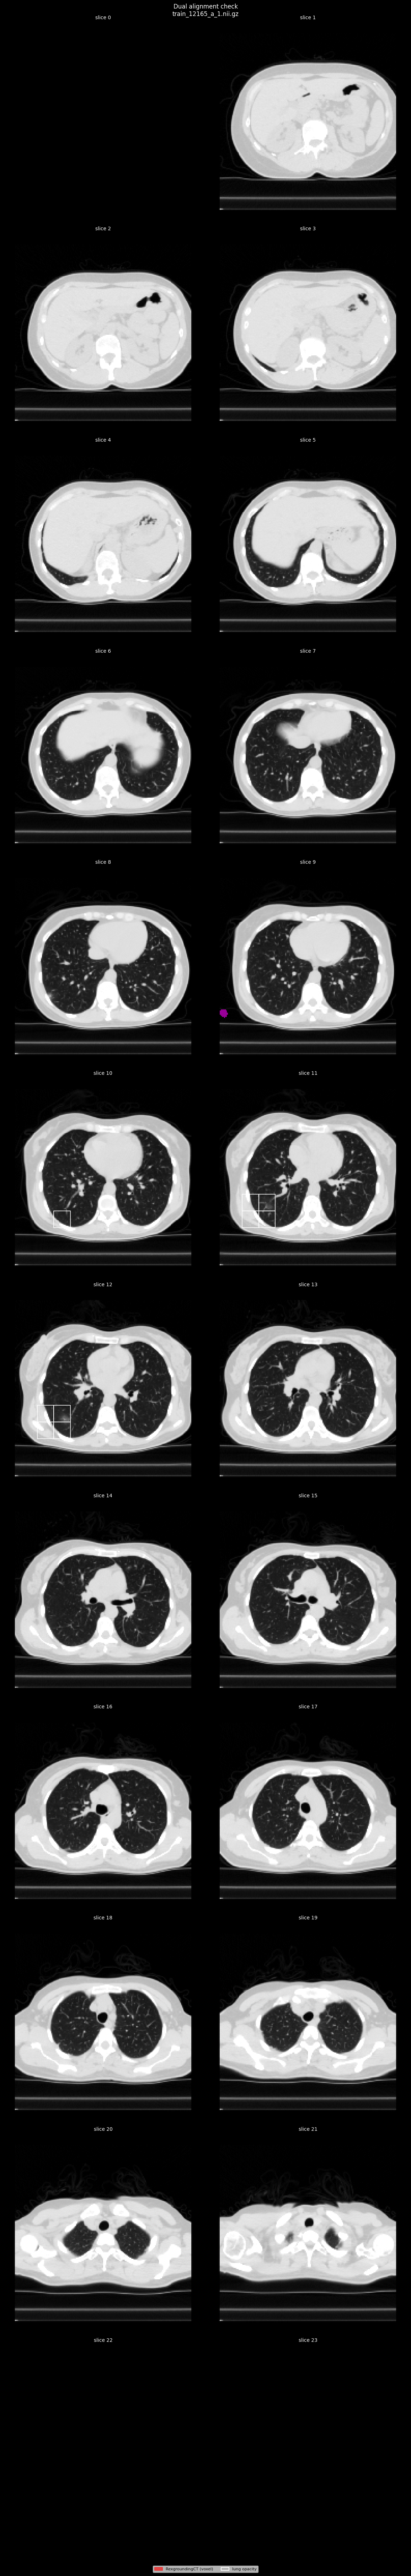

In [8]:
%matplotlib inline

ct_path = r"C:\Users\chamu\D\UOR\FYP\fyp\data\data_volumes\dataset\train_fixed\train_12165\train_12165_a\train_12165_a_1.nii.gz"
rex_mask_path = r"C:\Users\chamu\D\UOR\FYP\fyp\data\segmentations\segmentations\train_12165_a_1.nii.gz"
patch_ann_dir = r"C:\Users\chamu\D\UOR\FYP\fyp\data\patch-masks\annotations-train\train_12165_a_1"
out_path = r"dual_alignment_check.png"

print(f"Loading CT: {ct_path}")
ct_display = preprocess_ct_to_display_space(ct_path)          # (96,192,192)

print(f"Loading RexgroundingCT mask: {rex_mask_path}")
rex_display = preprocess_mask_to_display_space(rex_mask_path)  # (96,192,192)

print(f"Loading PatchChestCT annotations from: {patch_ann_dir}")
FINDING = "lung_opacity"  # finding index 0
all_patch_anns = _load_patch_annotations(patch_ann_dir)
patch_anns = {FINDING: all_patch_anns[FINDING]} if FINDING in all_patch_anns else {}
if not patch_anns:
    print(f"  (no '{FINDING}' annotation file found in {patch_ann_dir})")

ref_ct = ct_display[2::4]     # (24,192,192) - matches PatchChestCT's own reference slices
ref_rex = rex_display[2::4]   # (24,192,192) - same slice indices, for direct comparison

import math

PATCH_H = PATCH_W = 16

ncols = 2
nrows = math.ceil(24 / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 6, nrows * 6)
)

fig.patch.set_facecolor("black")

# Make axes always iterable
axes = np.array(axes).reshape(-1)

for idx in range(24):
    ax = axes[idx]
    ax.set_facecolor("black")

    ax.imshow(
        _apply_window(ref_ct[idx]),
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    seg = ref_rex[idx]
    ax.imshow(
        np.ma.masked_where(seg <= 0, seg),
        cmap="spring",
        alpha=0.6,
        interpolation="none"
    )

    ax.set_title(f"slice {idx}", color="white", fontsize=10)
    ax.axis("off")

    ann = next(iter(patch_anns.values()))

    for r in range(12):
        for c in range(12):
            if ann[idx, r, c]:
                rect = mpatches.Rectangle(
                    (c * PATCH_W, r * PATCH_H),
                    PATCH_W,
                    PATCH_H,
                    linewidth=1.2,
                    edgecolor="white",
                    facecolor="none"
                )
                ax.add_patch(rect)

# Hide unused axes (if any)
for idx in range(24, len(axes)):
    axes[idx].axis("off")

handles = [
    mpatches.Patch(
        edgecolor="red",
        facecolor="red",
        alpha=0.6,
        label="RexgroundingCT (voxel)",
        linewidth=1.5
    )
]

handles += [
    mpatches.Patch(
        edgecolor=PALETTE.get(d, "white"),
        facecolor="none",
        label=d.replace("_", " "),
        linewidth=1.5
    )
    for d in patch_anns
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    fontsize=8,
    framealpha=0.7,
    bbox_to_anchor=(0.5, -0.01)
)

plt.suptitle(
    f"Dual alignment check\n{os.path.basename(ct_path)}",
    color="white",
    fontsize=12,
    y=0.995
)

plt.tight_layout()

# Display directly in notebook
plt.show()

Rex mask: (192, 192, 96)
lung_opacity (192, 192, 96)


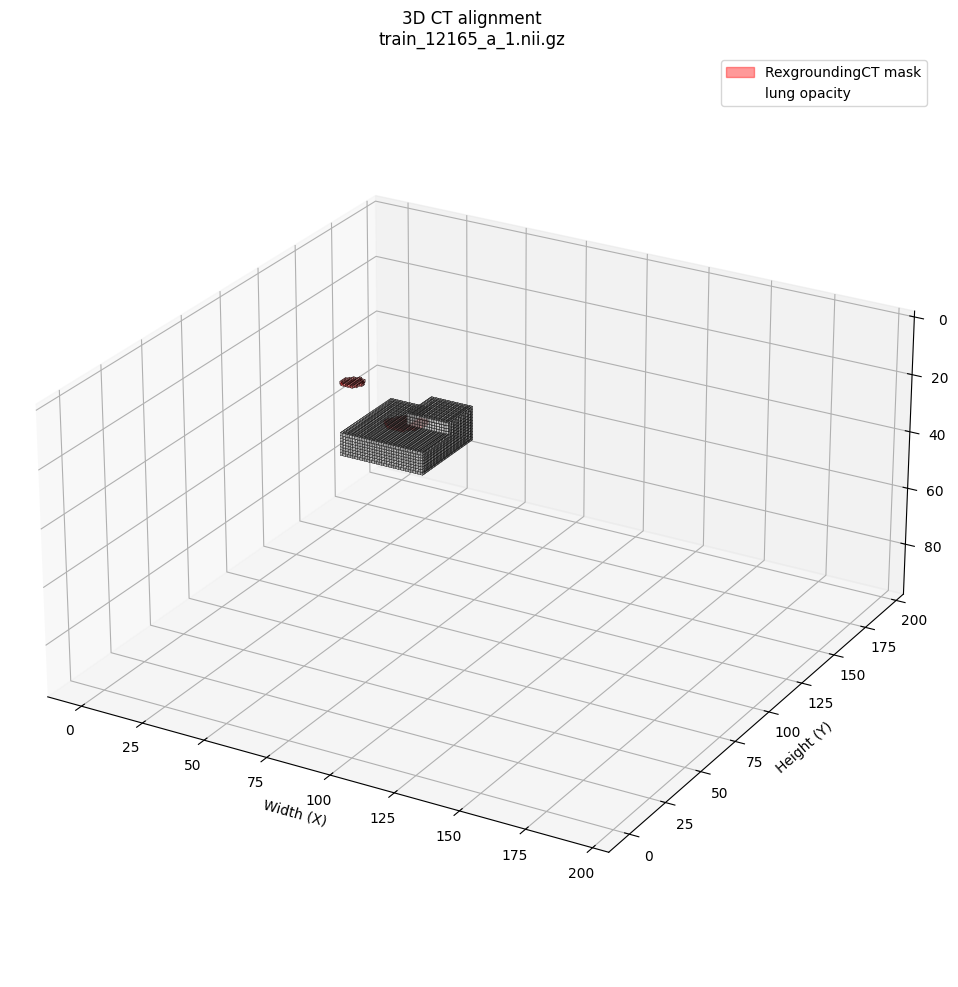

In [ ]:
# ── Prepare 3D masks ────────────────────────────────────────────────────────

# RexgroundingCT voxel mask
rex_mask_3d = (rex_display > 0).transpose(2, 1, 0)

# PatchChestCT annotations
patch_masks_3d = {}

for disease, ann in patch_anns.items():
    patch_masks_3d[disease] = _upsample_patch_annotation_to_voxel_grid(ann).transpose(2, 1, 0)

print("Rex mask:", rex_mask_3d.shape)
for d, m in patch_masks_3d.items():
    print(d, m.shape)

# VIS_DOWNSAMPLE = 0.5  # 0.5 = half resolution per axis -> ~1/8 the voxel count

# def _downsample_bool_mask(mask: np.ndarray, factor: float) -> np.ndarray:
#     return zoom(mask.astype(np.uint8), zoom=factor, order=0).astype(bool)

# rex_mask_3d = _downsample_bool_mask(rex_mask_3d, VIS_DOWNSAMPLE)
# patch_masks_3d = {
#     disease: _downsample_bool_mask(mask, VIS_DOWNSAMPLE)
#     for disease, mask in patch_masks_3d.items()
# }

# print("Rex mask (downsampled):", rex_mask_3d.shape)
# for d, m in patch_masks_3d.items():
#     print(d, m.shape)

# ── Plot ────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection="3d")

ax.set_box_aspect(rex_mask_3d.shape)   # already (W,H,D) after transpose above


# ---------------------------------------------------------------------------
# Plot RexgroundingCT voxel mask
# ---------------------------------------------------------------------------

if rex_mask_3d.any():

    ax.voxels(
        rex_mask_3d,
        facecolors="red",
        edgecolor="black",
        linewidth=0.15,
        alpha=0.25
    )


# ---------------------------------------------------------------------------
# Plot PatchChestCT annotations
# ---------------------------------------------------------------------------

for disease, mask in patch_masks_3d.items():

    if not mask.any():
        continue

    colour = PALETTE.get(disease, "white")

    ax.voxels(
        mask,
        facecolors=colour,
        edgecolor="black",
        linewidth=0.2,
        alpha=0.45
    )


# ---------------------------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------------------------

ax.set_xlabel("Width (X)")
ax.set_ylabel("Height (Y)")
ax.set_zlabel("Depth (Z)")


ax.invert_zaxis()

ax.view_init(
    elev=25,
    azim=-60
)


handles = [
    mpatches.Patch(
        color="red",
        alpha=0.4,
        label="RexgroundingCT mask"
    )
]


for disease in patch_masks_3d:
    handles.append(
        mpatches.Patch(
            color=PALETTE.get(disease, "white"),
            alpha=0.5,
            label=disease.replace("_", " ")
        )
    )


ax.legend(
    handles=handles,
    loc="upper right"
)


plt.title(
    f"3D CT alignment\n{os.path.basename(ct_path)}"
)


plt.show()

In [9]:
# ── Coverage: % of positive RexgroundingCT voxels covered by annotation patches ──

rex_positive = rex_display > 0          # (96,192,192) bool, still in (D,H,W) order — no transpose needed here

# Union of all patch masks currently loaded (just lung_opacity, given the earlier filter)
patch_union = np.zeros_like(rex_positive, dtype=bool)
for disease, ann in patch_anns.items():
    patch_union |= _upsample_patch_annotation_to_voxel_grid(ann)

total_positive = rex_positive.sum()
covered = (rex_positive & patch_union).sum()

if total_positive == 0:
    print("RexgroundingCT mask has no positive voxels in the display grid — nothing to compute.")
else:
    pct = 100.0 * covered / total_positive
    print(f"Positive RexgroundingCT voxels : {total_positive}")
    print(f"Voxels covered by annotation patches: {covered}")
    print(f"Coverage of voxels by patches: {pct:.2f}%")

Positive RexgroundingCT voxels : 176
Voxels covered by annotation patches: 129
Coverage of voxels by patches: 73.30%


In [10]:
# ── Patch-level coverage stats ──────────────────────────────────────────────
# Counted on the native (24,12,12) patch grid, not the upsampled voxel grid,
# so each patch is counted once regardless of its 4x16x16 voxel footprint.

def _downsample_mask_to_patch_grid(voxel_mask: np.ndarray) -> np.ndarray:
    """
    (96,192,192) bool voxel mask -> (24,12,12) bool patch grid.
    A patch counts as True if ANY voxel inside it is True (matches how
    annotators would have seen/marked a patch as positive).
    """
    d, h, w = voxel_mask.shape
    reshaped = voxel_mask.reshape(d // 4, 4, h // 16, 16, w // 16, 16)
    return reshaped.any(axis=(1, 3, 5))  # -> (24,12,12)


rex_patch_grid = _downsample_mask_to_patch_grid(rex_display > 0)  # (24,12,12)

print(f"{'Finding':<20} {'# annotated patches':<22} {'# overlapping RexgroundingCT':<30} {'% overlap'}")
for disease, ann in patch_anns.items():
    n_annotated = int(ann.sum())
    n_overlap = int((ann & rex_patch_grid).sum())
    pct = (n_overlap / n_annotated * 100) if n_annotated else 0.0
    print(f"{disease:<20} {n_annotated:<22} {n_overlap:<30} {pct:.1f}%")

Finding              # annotated patches    # overlapping RexgroundingCT   % overlap
lung_opacity         9                      1                              11.1%


In [11]:
# ── Per-disease patch overlap aggregation across all common volumes ─────────
# For atelectasis, lung_opacity, consolidation, bronchiectasis:
#   - load that disease's native (24,12,12) patch annotation for every common
#     case that has it
#   - load the RexgroundingCT segmentation mask and downsample it to the same
#     (24,12,12) patch grid
#   - count patches that are annotated AND overlap a Rex-positive patch
#
# Exclusion rules:
#   - a case missing a given disease's .npz is excluded from that disease's
#     stats only (many cases don't have every finding)
#   - a case whose RexgroundingCT mask is missing/unreadable is skipped
#     entirely (warning printed) and excluded from ALL diseases' stats

import pandas as pd

TARGET_DISEASES = ["atelectasis", "lung_opacity", "consolidation", "bronchiectasis"]

# Root of the data folder, derived the same way the paths in the first cell are laid out
data_root = os.path.dirname(os.path.dirname(dataset_json))
rex_segmentations_dir = os.path.join(data_root, "segmentations", "segmentations")


def _find_annotation_dir(case: str):
    """Return the case's annotation folder, checking train then valid."""
    for base in (train_annotations_dir, val_annotations_dir):
        candidate = os.path.join(base, case)
        if os.path.isdir(candidate):
            return candidate
    return None


per_disease_stats = {
    disease: {"n_cases": 0, "n_annotated": 0, "n_overlap": 0}
    for disease in TARGET_DISEASES
}
skipped_cases = []

for case in sorted(common):
    rex_mask_path = os.path.join(rex_segmentations_dir, f"{case}.nii.gz")

    try:
        rex_display_case = preprocess_mask_to_display_space(rex_mask_path)  # (96,192,192)
    except Exception as exc:
        print(f"[WARN] Skipping {case}: failed to load RexgroundingCT mask ({exc})")
        skipped_cases.append(case)
        continue

    rex_patch_grid_case = _downsample_mask_to_patch_grid(rex_display_case > 0)  # (24,12,12)

    ann_dir = _find_annotation_dir(case)
    if ann_dir is None:
        continue

    case_anns = _load_patch_annotations(ann_dir)

    for disease in TARGET_DISEASES:
        if disease not in case_anns:
            continue  # this case has no annotation for this finding -> excluded from its stats

        ann = case_anns[disease]
        n_annotated = int(ann.sum())
        n_overlap = int((ann & rex_patch_grid_case).sum())

        per_disease_stats[disease]["n_cases"] += 1
        per_disease_stats[disease]["n_annotated"] += n_annotated
        per_disease_stats[disease]["n_overlap"] += n_overlap

print(f"Skipped {len(skipped_cases)} case(s) with missing/unreadable RexgroundingCT masks: {skipped_cases}\n")

rows = []
for disease in TARGET_DISEASES:
    s = per_disease_stats[disease]
    pct = (s["n_overlap"] / s["n_annotated"] * 100) if s["n_annotated"] else 0.0
    rows.append({
        "disease": disease,
        "n_cases": s["n_cases"],
        "n_annotated_patches": s["n_annotated"],
        "n_overlapping_patches": s["n_overlap"],
        "pct_overlap": round(pct, 1),
    })

disease_overlap_df = pd.DataFrame(rows)
print(disease_overlap_df.to_string(index=False))
disease_overlap_df

Skipped 0 case(s) with missing/unreadable RexgroundingCT masks: []

       disease  n_cases  n_annotated_patches  n_overlapping_patches  pct_overlap
   atelectasis       22                   65                     22         33.8
  lung_opacity       62                 5650                    497          8.8
 consolidation       32                  536                     53          9.9
bronchiectasis       12                   50                     14         28.0


,disease,n_cases,n_annotated_patches,n_overlapping_patches,pct_overlap
0,atelectasis,22,65,22,33.8
1,lung_opacity,62,5650,497,8.8
2,consolidation,32,536,53,9.9
3,bronchiectasis,12,50,14,28.0
